Attempting to load: /home/midori/Desktop/Machine-Learning/Data/student_performance.csv
Loaded with separator: ',' — shape: (1000000, 6)
Detected final-grade column: 'grade'

Feature matrix shape: (1000000, 5)
Target distribution:
 grade_class
Missing    1000000
Name: count, dtype: int64

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

     Missing       1.00      1.00      1.00    200000

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



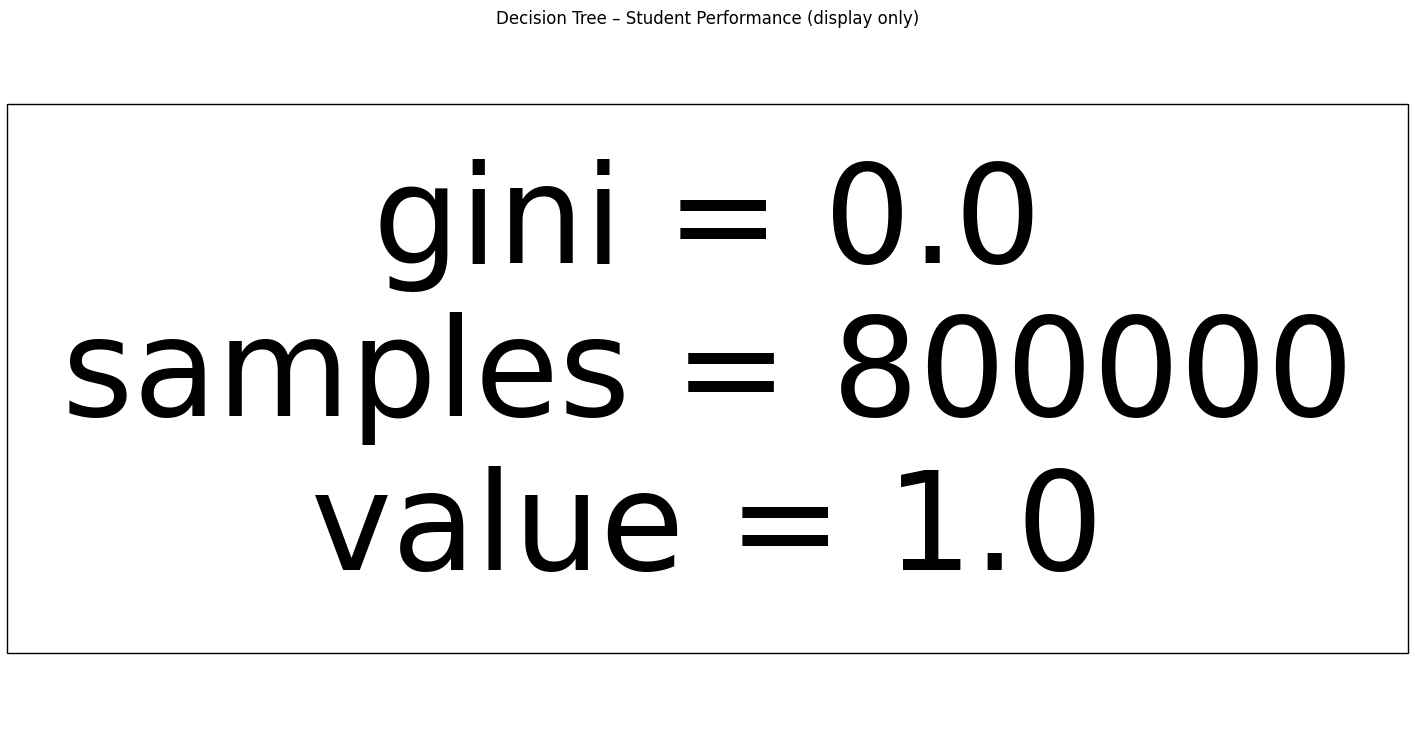

In [2]:
# Decision Tree on Student Performance Dataset — robust grade detection (no file writes)
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ---------- CONFIG ----------
PROJECT_ROOT = "/home/midori/Desktop/Machine-Learning"   # <--- keep this (or edit to your project root)
DATA_DIR = os.path.join(PROJECT_ROOT, "Data")
STUDENT_PATH_CSV = os.path.join(DATA_DIR, "student_performance.csv")

# ---------- HELPER: robust read ----------
def robust_read_csv(path):
    """
    Try reading CSV by guessing separator. Return DataFrame and used separator.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    # Try default first
    df1 = pd.read_csv(path)
    # If it has 1 column (likely wrong sep), try semicolon
    if df1.shape[1] == 1:
        try:
            df2 = pd.read_csv(path, sep=';')
            # choose the one with more columns
            if df2.shape[1] > df1.shape[1]:
                return df2, ';'
        except Exception:
            pass
    # Sometimes semicolon file may still be read with comma; also try explicit semicolon always if ambiguous
    try:
        df_semicolon = pd.read_csv(path, sep=';')
        if df_semicolon.shape[1] > df1.shape[1]:
            return df_semicolon, ';'
    except Exception:
        pass
    return df1, ','

# ---------- HELPER: detect grade column ----------
def detect_grade_column(df):
    cols = list(df.columns)
    lc = [c.lower().strip() for c in cols]
    # 1) direct name matches (priority)
    name_priority = ['g3', 'final', 'final_grade', 'finalgrade', 'grade', 'grades', 'g_3', 'g_2', 'g1']
    for p in name_priority:
        for c, cl in zip(cols, lc):
            if cl == p:
                return c
    # 2) substring matches (contains)
    substrings = ['g3', 'g_3', 'final', 'grade', 'g3.0']
    for s in substrings:
        for c, cl in zip(cols, lc):
            if s in cl:
                return c
    # 3) numeric inference: find numeric columns with typical school-grade ranges (0..20 or 0..100)
    numeric_cols = []
    for c in cols:
        # coerce numeric
        series = pd.to_numeric(df[c], errors='coerce')
        non_null = series.dropna()
        if non_null.empty:
            continue
        mn, mx = non_null.min(), non_null.max()
        # plausible grade ranges
        if (mn >= -1) and (mx <= 100):   # allow broad range
            numeric_cols.append((c, float(mn), float(mx), len(non_null)))
    if numeric_cols:
        # prefer columns with max <= 20 (typical for G3), then prefer more non-null
        candidates = [t for t in numeric_cols if t[2] <= 20]
        if not candidates:
            candidates = numeric_cols
        # sort by number of non-null desc, then by narrowest range to prefer grade-like
        candidates.sort(key=lambda x: (-x[3], x[2]-x[1]))
        return candidates[0][0]
    # none found
    return None

# ---------- Main flow ----------
print("Attempting to load:", STUDENT_PATH_CSV)
df, used_sep = robust_read_csv(STUDENT_PATH_CSV)
print(f"Loaded with separator: '{used_sep}' — shape: {df.shape}")

# If grade_class column already exists, use it
if 'grade_class' in df.columns:
    target_col = 'grade_class'
    print("Found existing 'grade_class' column; using it as target.")
else:
    # detect grade column
    grade_col = detect_grade_column(df)
    if grade_col is None:
        print("\nERROR: Could not automatically detect the final-grade column (e.g., 'G3').")
        print("Columns in the file:\n")
        for i, c in enumerate(df.columns):
            dtype = df[c].dtype
            # show small sample values
            sample = df[c].dropna().unique()[:6].tolist()
            print(f" {i:02d}: {c}  (dtype={dtype})  sample={sample}")
        raise KeyError("Please inspect the above column list and supply the final-grade column name (e.g., 'G3').")
    else:
        target_col = grade_col
        print(f"Detected final-grade column: '{target_col}'")

# Convert to numeric if possible (coerce)
if target_col != 'grade_class':
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    # If more than 40% missing after coercion, warn
    missing_frac = df[target_col].isna().mean()
    if missing_frac > 0.4:
        print(f"Warning: {missing_frac*100:.1f}% values in detected grade column '{target_col}' are non-numeric/missing.")

# If numeric grades, bin into Low/Medium/High if not already categorical
if df[target_col].dtype.kind in 'biufc':  # numeric
    def grade_category(g):
        if pd.isna(g):
            return "Missing"
        if g < 10:
            return "Low"
        elif g < 15:
            return "Medium"
        else:
            return "High"
    df["grade_class"] = df[target_col].apply(grade_category)
else:
    # assume categorical already
    df["grade_class"] = df[target_col].astype(str)

# Drop raw grade columns if present to avoid leakage
for c in ['G1', 'G2', 'G3', target_col]:
    if c in df.columns:
        try:
            df.drop(columns=[c], inplace=True)
        except Exception:
            pass  # safe

# One-hot encode features (safe)
df_enc = pd.get_dummies(df, drop_first=True)

# Ensure 'grade_class' exists in original df (it does), map target
y = df["grade_class"]
X = df_enc.drop(columns=["grade_class"], errors='ignore') if "grade_class" in df_enc.columns else df_enc

# quick sanity checks
print("\nFeature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts(dropna=False))

# Train-test split (if too few classes or samples, stratify might fail — handle)
stratify_arg = y if (y.nunique() > 1 and y.shape[0] >= 10) else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)

# Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Plot tree (display only)
plt.figure(figsize=(18, 9))
plot_tree(model, max_depth=3, filled=True,
          feature_names=X.columns if X.shape[1] <= 200 else None,
          class_names=[str(c) for c in model.classes_])
plt.title("Decision Tree – Student Performance (display only)")
plt.show()
